In [29]:
!pip install earthpy

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 5.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ------ --------------------------------- 2.1/12.9 MB 19.5 MB/s eta 0:00:01
   ------- -------------------------------- 2.4/12.9 MB 6.1 MB/s eta 0:00:02
   -------- ------------------------------- 2.6/12.9 MB 3.9 MB/s eta 0:00:03
   -------- ------------------------------- 2.9/12.9 MB 3.4 MB/s eta 0:00:03
   --------- ------------------------------ 3.1/12.9 MB 3.5 MB/s eta 0:00:03
   ----------- ---------------------------- 3.7/12.9 MB 2.9 MB/s eta 0:00:04
   ------------- -------------------------- 4.2/12.9 MB 2.8 MB/s eta 0:00:04
   ------------- -------------------------- 4.5/12.9 MB 2.7 MB/s eta 0:00:04
   -------------- ------------------------- 4.7/12.9 MB 2.5 MB/s eta 0:00:04
   ---------------- --

In [56]:
import earthpy as ep
import earthpy.plot as epp
import earthpy.spatial as es
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import os
import numpy as np
from glob import glob
import rasterio as rs
from rasterio.plot import reshape_as_raster, reshape_as_image

In [57]:
datasets = ['california-rim-fire', 'co-flood-extras', 'cold-springs-fire', 'cold-springs-landsat-scenes',
            'cold-springs-modis-h4', 'colorado-flood', 'cs-test-landsat', 'cs-test-naip', 'naip-fire-crop', 'ndvi-automation', 
            'spatial-vector-lidar', 'twitter-flood', 'vignette-elevation', 'vignette-landsat']
for n, i in enumerate(datasets):
  print('%3d. %s'%(n+1,i))

  1. california-rim-fire
  2. co-flood-extras
  3. cold-springs-fire
  4. cold-springs-landsat-scenes
  5. cold-springs-modis-h4
  6. colorado-flood
  7. cs-test-landsat
  8. cs-test-naip
  9. naip-fire-crop
 10. ndvi-automation
 11. spatial-vector-lidar
 12. twitter-flood
 13. vignette-elevation
 14. vignette-landsat


In [58]:
#Specify the directory to download data to
ep.data.path = 'data'

In [59]:
# Find path notebook is running
!cd

C:\Users\Carlt\Desktop\sample_project5


In [60]:
# Specify the dataset name to download
data = ep.data.get_data('vignette-landsat')

### Read Data

In [61]:
landsat_path = glob("data/vignette-landsat/LC08_L1TP_034032_20160621_20170221_01_T1_sr_band*_crop.tif")
landsat_path.sort()
arr_st, meta = es.stack(landsat_path, nodata=-9999)

In [62]:
# Printing the metadata
for i, j in meta.items():
    print('%10s : %s'%(i, str(j)))

    driver : GTiff
     dtype : int16
    nodata : -9999.0
     width : 2158
    height : 1941
     count : 7
       crs : PROJCS["WGS 84 / UTM zone 13N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-105],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
 transform : | 30.00, 0.00, 449085.00|
| 0.00,-30.00, 4434855.00|
| 0.00, 0.00, 1.00|
blockxsize : 2158
blockysize : 1
     tiled : False
interleave : band


### Plot the Bands

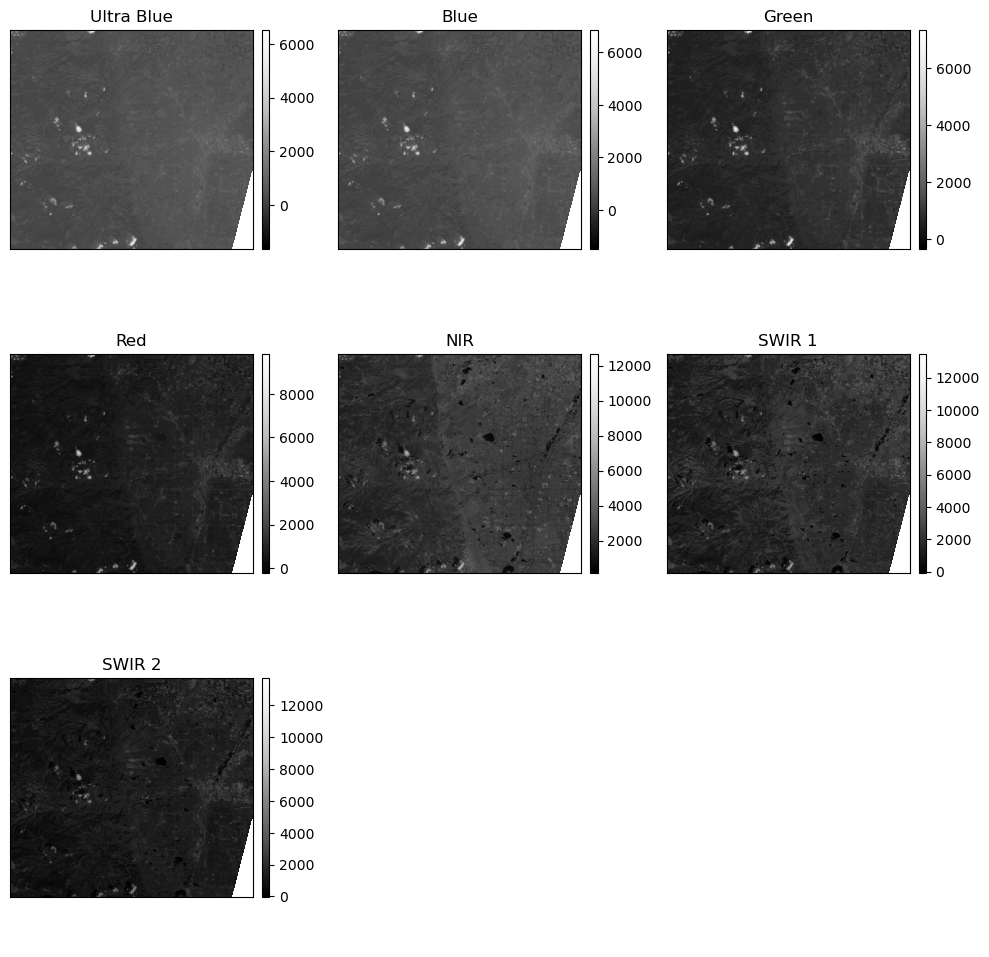

In [63]:
titles = ["Ultra Blue", "Blue", "Green", "Red", "NIR", "SWIR 1", "SWIR 2"]
f = epp.plot_bands(arr_st, #cmap='RdYlGn',
                   figsize=(10,10), title=titles)

#plt.show()

### RGB Composite Image

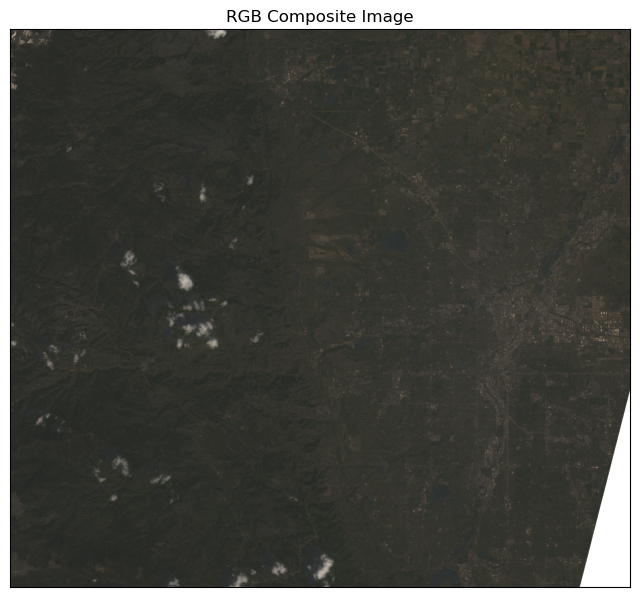

In [64]:
rgb = epp.plot_rgb(arr_st, rgb=(3,2,1), figsize=(8, 8), title='RGB Composite Image')
plt.show()

In [65]:
# Checking the first 5 values in the row and column of the first image
arr_st[1, :5, :5]

masked_array(
  data=[[597, 710, 867, 974, 905],
        [624, 699, 845, 897, 923],
        [611, 646, 771, 850, 887],
        [582, 590, 741, 815, 831],
        [565, 584, 722, 815, 837]],
  mask=[[False, False, False, False, False],
        [False, False, False, False, False],
        [False, False, False, False, False],
        [False, False, False, False, False],
        [False, False, False, False, False]],
  fill_value=-9999,
  dtype=int16)

### Stretch Composite Image

C:\Users\Carlt\Desktop\sample_project5\env\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


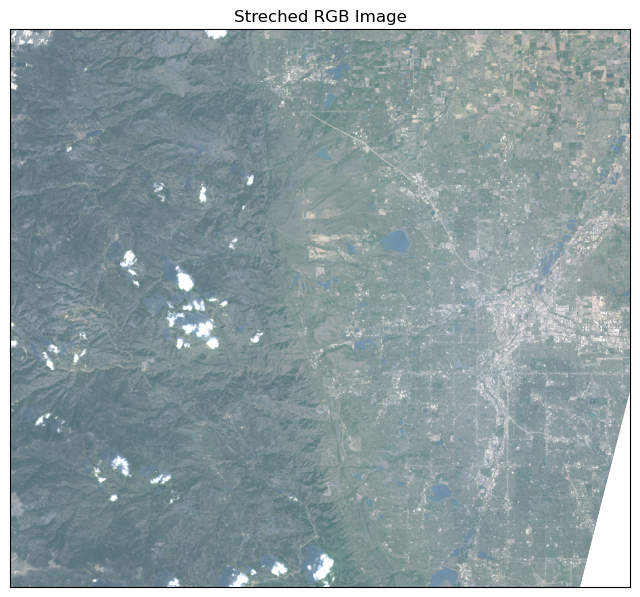

In [66]:
epp.plot_rgb(
    arr_st, rgb=(3, 2, 1), stretch=True, str_clip=0.8, figsize=(8,8),
    title = 'Streched RGB Image'
)
plt.show()

### Plotting Color Infra Red Composite Image

Here we shall plot bands 5(Infra red), 4(Red), 3(Green) 

C:\Users\Carlt\Desktop\sample_project5\env\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


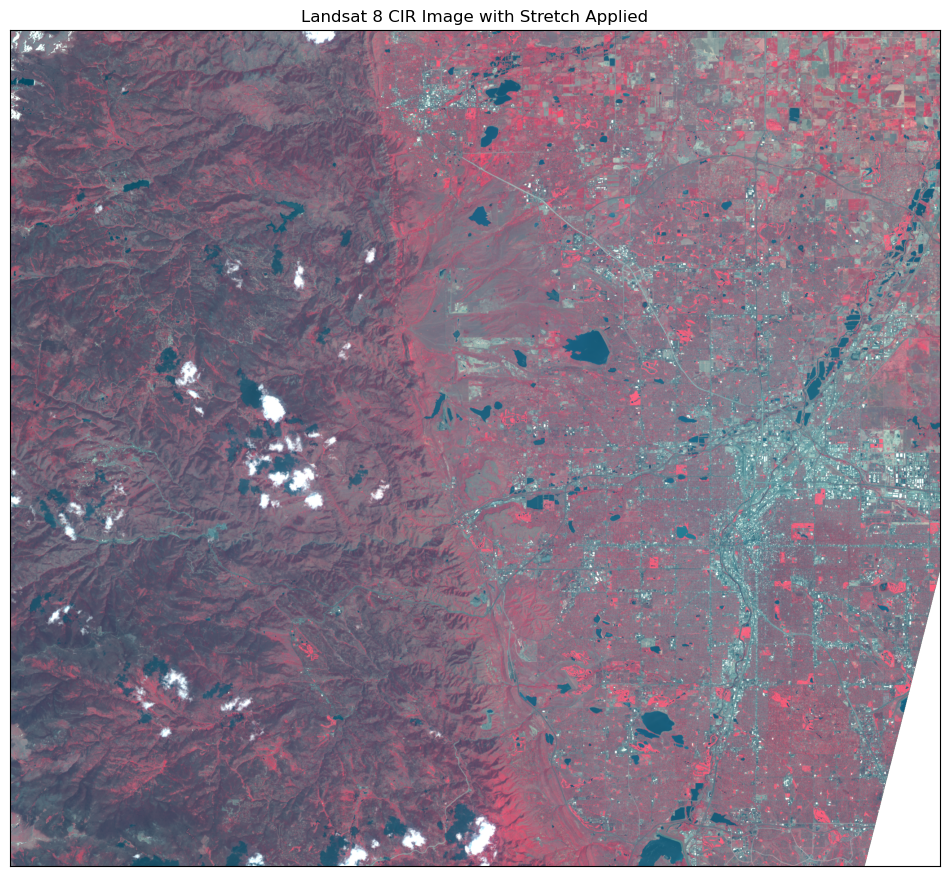

In [76]:
# Create figure with one plot
fig, ax = plt.subplots(figsize=(12, 12))

# Plot NIR, red, and green bands, respectively, with stretch
epp.plot_rgb(
    arr_st,
    rgb=(4, 3, 2),
    ax=ax,
    stretch=True,
    str_clip=0.5,
    title="Landsat 8 CIR Image with Stretch Applied",
)
plt.show()

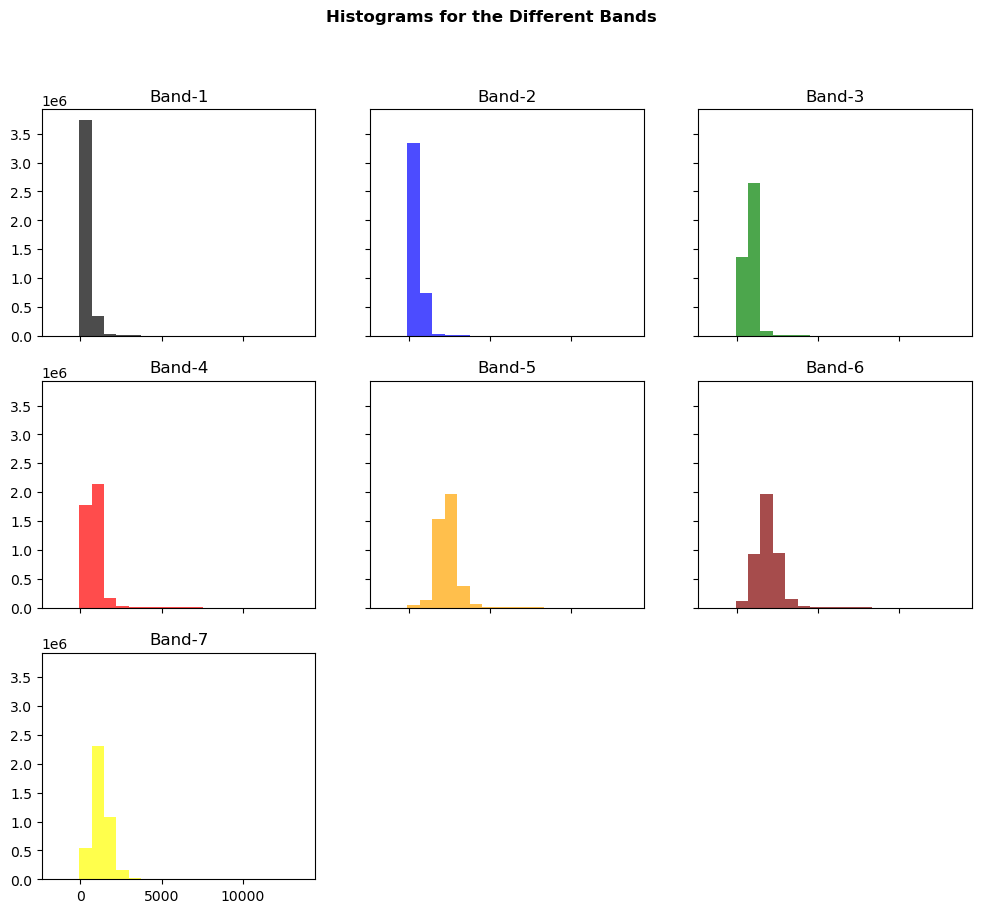

In [67]:
# Plot the histograms w.r.t Bands
colors = ['black', 'blue', 'green', 'red', 'orange', 'maroon', 'yellow']

epp.hist(arr_st, colors = colors, title=[f'Band-{i}' for i in range(1, 8)], cols=3, alpha=0.7, figsize = (12, 10), )
plt.suptitle('Histograms for the Different Bands', weight='bold')

plt.show()

### Extract Spectral and Plot

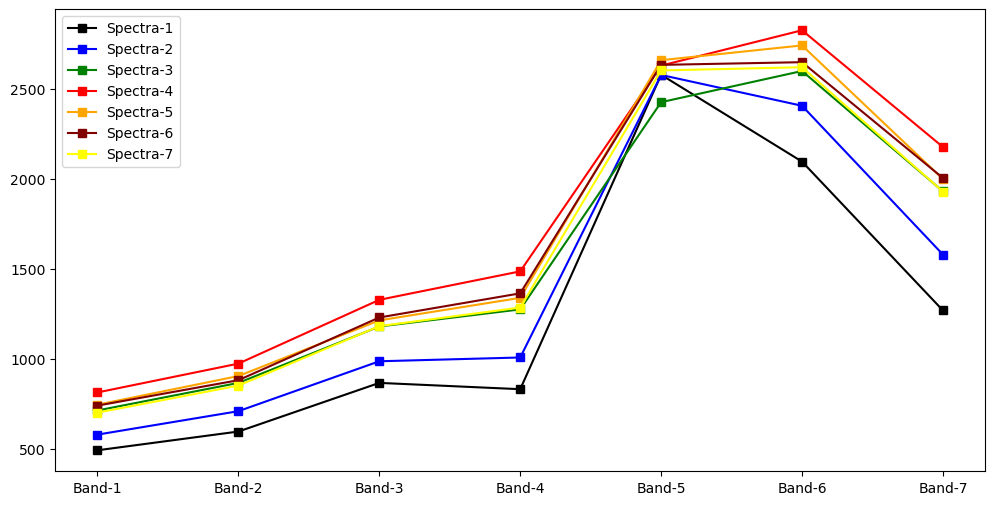

In [69]:
plt.figure(figsize=(12, 6))
for i, c in enumerate(colors):
    plt.plot(np.asarray(arr_st[:, 0, i]), '-s', color=c, label=f'Spectra-{i+1}')
plt.xticks(range(7), [f'Band-{i}' for i in range(1, 8)])
plt.legend()
plt.show()

### Calculating Normalized Difference Vagetation Index(NDVI)

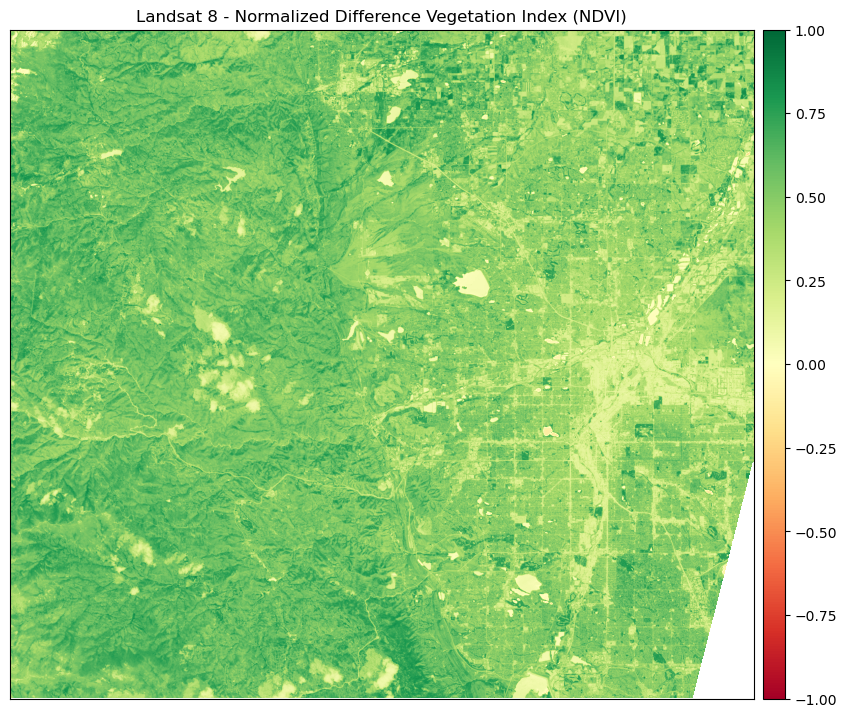

In [71]:
# Landsat 8 red band is band 4 at [3]
# Landsat 8 near-infrared band is band 5 at [4]

ndvi = es.normalized_diff(arr_st[4], arr_st[3])
titles = ["Landsat 8 - Normalized Difference Vegetation Index (NDVI)"]
epp.plot_bands(ndvi, cmap = 'RdYlGn', title=titles, vmin=-1, vmax=1, figsize=(10, 10))
plt.show()

### Classify NDVI

In [72]:
# Create Classes and apply to NDVI results
ndvi_class_bins = [-np.inf, 0, 0.15, 0.23, 0.6, np.inf]

ndvi_landsat_class = np.digitize(ndvi, ndvi_class_bins)

#Apply the nodata mask to the newly classified NDVI data
ndvi_landsat_class = np.ma.masked_where(np.ma.getmask(ndvi), ndvi_landsat_class)

np.unique(ndvi_landsat_class)

masked_array(data=[1, 2, 3, 4, 5, --],
             mask=[False, False, False, False, False,  True],
       fill_value=999999,
            dtype=int64)

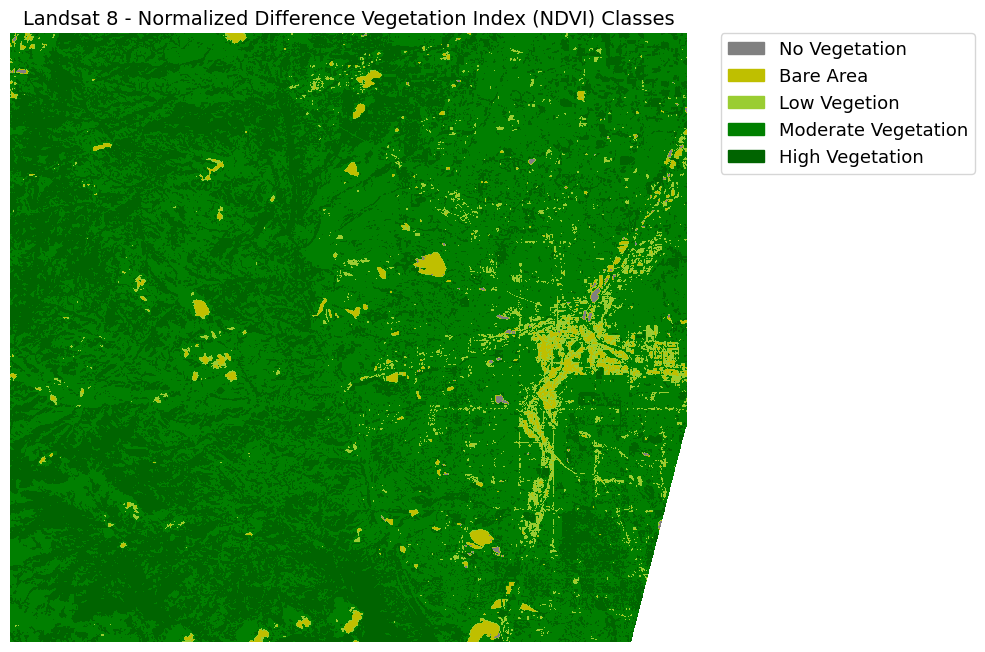

In [74]:
nbr_colors = ["gray", "y", "yellowgreen", "g", "darkgreen"]
nbr_cmap = ListedColormap(nbr_colors)

#Define class names
ndvi_cat_names = [
    'No Vegetation',
    'Bare Area',
    'Low Vegetion',
    'Moderate Vegetation',
    'High Vegetation'
]

# Get list of classes
classes = np.unique(ndvi_landsat_class)
classes = classes.tolist()
#The mask returns a value of name in the classes, remove the value
classes=classes[:5]

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(ndvi_landsat_class, cmap=nbr_cmap)

epp.draw_legend(im_ax=im, classes=classes, titles=ndvi_cat_names)
ax.set_title(
    "Landsat 8 - Normalized Difference Vegetation Index (NDVI) Classes",
    fontsize=14,
)
ax.set_axis_off()

# Auto adjust subplot to fit figure size
plt.tight_layout()